# Classification of Regulatory Text with Uncertainty Assessment

An approach of categorizing ECOA, FCRA, and TILA regulatory text is proposed in this study. The system integrates uncertainty estimation using entropy and margin alongside prediction to facilitate risk-aware decision-making and abstention in ambiguous situations.

The notebook also collects repeatable artifacts, including saved figures and multi-run outputs, to chronicle project advancement and model stability.


## Environment Setup

In [1]:
!pip install gensim scikit-learn matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import entropy

## Environment Sanity Check

This section confirms that the required libraries and core functions are working before the project pipeline is executed.

In [3]:
print("Checking environment...")

sentences_test = [["test", "word2vec"], ["another", "test"]]
test_model = Word2Vec(sentences_test, vector_size=10, min_count=1)

X_test = np.array([[0.1, 0.2], [0.2, 0.3]])
y_test = ["A", "B"]
clf_test = LogisticRegression().fit(X_test, y_test)

test_entropy = entropy([0.7, 0.3])

plt.figure()
plt.plot([1, 2], [3, 4])
plt.close()

print("Environment ready.")

Checking environment...
Environment ready.


## Problem Definition

The objective is to classify regulatory text into:
- ECOA (Equal Credit Opportunity Act)
- FCRA (Fair Credit Reporting Act)
- TILA (Truth in Lending Act)

Beyond classification, the system evaluates uncertainty using entropy and margin so it can abstain when confidence is low.

## Dataset

A small labeled dataset is created to support the regulatory classification task.

In [4]:
data = [
    ("loan applicant claims discrimination in credit approval", "ECOA"),
    ("creditor considered marital status in lending decision", "ECOA"),
    ("applicant was denied credit unfairly", "ECOA"),
    ("borrower alleges discriminatory lending treatment", "ECOA"),
    ("credit decision may have been influenced by protected characteristics", "ECOA"),

    ("consumer disputes incorrect credit report entry", "FCRA"),
    ("credit report shows inaccurate delinquency", "FCRA"),
    ("agency failed to correct false credit history", "FCRA"),
    ("consumer reporting agency reported inaccurate account status", "FCRA"),
    ("borrower challenges an error in the credit file", "FCRA"),

    ("borrower did not receive truth in lending disclosure", "TILA"),
    ("loan terms were not clearly disclosed", "TILA"),
    ("lender failed to provide required APR disclosure", "TILA"),
    ("finance charges were not properly explained", "TILA"),
    ("consumer did not receive required disclosure of loan costs", "TILA")
]

df = pd.DataFrame(data, columns=["text", "label"])
df

,text,label
0,loan applicant claims discrimination in credit...,ECOA
1,creditor considered marital status in lending ...,ECOA
2,applicant was denied credit unfairly,ECOA
3,borrower alleges discriminatory lending treatment,ECOA
4,credit decision may have been influenced by pr...,ECOA
5,consumer disputes incorrect credit report entry,FCRA
6,credit report shows inaccurate delinquency,FCRA
7,agency failed to correct false credit history,FCRA
8,consumer reporting agency reported inaccurate ...,FCRA
9,borrower challenges an error in the credit file,FCRA


## Data Inspection

In [5]:
print(df.head())
print(df["label"].value_counts())

                                                text label
0  loan applicant claims discrimination in credit...  ECOA
1  creditor considered marital status in lending ...  ECOA
2               applicant was denied credit unfairly  ECOA
3  borrower alleges discriminatory lending treatment  ECOA
4  credit decision may have been influenced by pr...  ECOA
label
ECOA    5
FCRA    5
TILA    5
Name: count, dtype: int64


## Text Processing

The text is normalized and tokenized to prepare it for embedding generation.

In [6]:
sentences = [text.lower().split() for text in df["text"]]
sentences[:3]

[['loan', 'applicant', 'claims', 'discrimination', 'in', 'credit', 'approval'],
 ['creditor', 'considered', 'marital', 'status', 'in', 'lending', 'decision'],
 ['applicant', 'was', 'denied', 'credit', 'unfairly']]

## Word Embeddings

Word2Vec is used to generate semantic vector representations of words from the regulatory corpus.

In [7]:
model = Word2Vec(
    sentences,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1
)

## Embedding Check

This section verifies that the learned embeddings capture meaningful relationships between words.

In [8]:
model.wv.most_similar("credit")

[('status', 0.27122172713279724),
 ('treatment', 0.26937657594680786),
 ('correct', 0.25482919812202454),
 ('truth', 0.240776926279068),
 ('agency', 0.21113936603069305),
 ('was', 0.19620950520038605),
 ('properly', 0.18595898151397705),
 ('reported', 0.1758371740579605),
 ('did', 0.16690614819526672),
 ('explained', 0.16088640689849854)]

In [9]:
model.wv.similarity("credit", "loan")

np.float32(0.13213111)

## Sentence Representation

Each sentence is converted into a single vector by averaging the vectors of its words.

In [10]:
def sentence_vector(tokens, w2v_model):
    vectors = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
    return np.mean(vectors, axis=0)

X = np.array([sentence_vector(text.lower().split(), model) for text in df["text"]])
y = df["label"]

## Classification Model

A Logistic Regression classifier is trained on sentence vectors to predict ECOA, FCRA, or TILA.

In [11]:
clf = LogisticRegression()
clf.fit(X, y)

preds = clf.predict(X)
probs = clf.predict_proba(X)

## Performance

In [12]:
print(classification_report(y, preds))

              precision    recall  f1-score   support

        ECOA       1.00      1.00      1.00         5
        FCRA       1.00      1.00      1.00         5
        TILA       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



## Entropy (Uncertainty)

Entropy measures how uncertain the classifier is across the class probability distribution.

In [13]:
entropy_scores = [entropy(p) for p in probs]
entropy_scores

[np.float64(1.0986117937516164),
 np.float64(1.0986121244246017),
 np.float64(1.098611818736025),
 np.float64(1.0986119080028856),
 np.float64(1.0986120491235842),
 np.float64(1.0986121015129615),
 np.float64(1.0986117486732505),
 np.float64(1.0986121537062952),
 np.float64(1.0986118694414633),
 np.float64(1.0986121899272259),
 np.float64(1.0986122244832233),
 np.float64(1.0986120471562668),
 np.float64(1.0986121141527263),
 np.float64(1.0986121044209793),
 np.float64(1.0986121572227128)]

## Margin (Confidence)

Margin measures the separation between the top two predicted class probabilities. Larger margins indicate stronger confidence.

In [14]:
def margin(p):
    p = sorted(p, reverse=True)
    return p[0] - p[1]

margins = [margin(p) for p in probs]
margins

[np.float64(0.00040951411609130295),
 np.float64(0.00039596179260625863),
 np.float64(0.00019781808302804516),
 np.float64(0.0005880788385597135),
 np.float64(0.0003895459248183797),
 np.float64(0.0002579909449546003),
 np.float64(0.0007307608400187737),
 np.float64(0.00034009819721686485),
 np.float64(0.0006167782020774504),
 np.float64(0.00019431027943084267),
 np.float64(0.0002530839016917641),
 np.float64(0.00032134928130361784),
 np.float64(0.000359088592950807),
 np.float64(0.000363443565574606),
 np.float64(0.0003181714512935918)]

## Abstention Strategy

Predictions are withheld when uncertainty exceeds a defined threshold.

In [15]:
for i in range(len(df)):
    decision = "ABSTAIN" if entropy_scores[i] > 0.9 else preds[i]
    print(df["text"][i], "→", decision)

loan applicant claims discrimination in credit approval → ABSTAIN
creditor considered marital status in lending decision → ABSTAIN
applicant was denied credit unfairly → ABSTAIN
borrower alleges discriminatory lending treatment → ABSTAIN
credit decision may have been influenced by protected characteristics → ABSTAIN
consumer disputes incorrect credit report entry → ABSTAIN
credit report shows inaccurate delinquency → ABSTAIN
agency failed to correct false credit history → ABSTAIN
consumer reporting agency reported inaccurate account status → ABSTAIN
borrower challenges an error in the credit file → ABSTAIN
borrower did not receive truth in lending disclosure → ABSTAIN
loan terms were not clearly disclosed → ABSTAIN
lender failed to provide required APR disclosure → ABSTAIN
finance charges were not properly explained → ABSTAIN
consumer did not receive required disclosure of loan costs → ABSTAIN


## Entropy Distribution

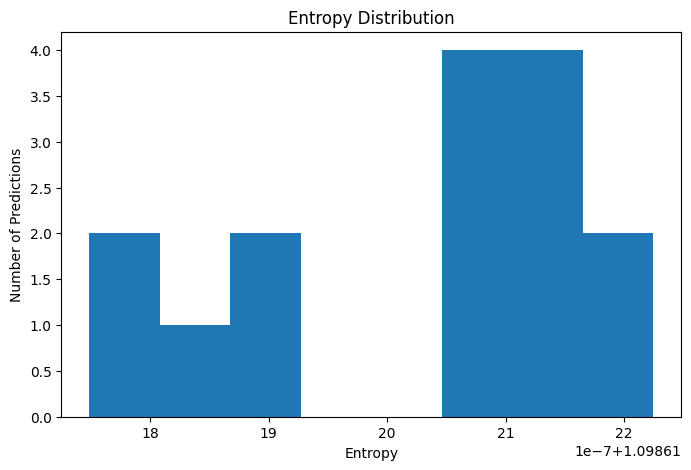

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(entropy_scores, bins=8)
plt.xlabel("Entropy")
plt.ylabel("Number of Predictions")
plt.title("Entropy Distribution")
plt.savefig("entropy_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Margin Distribution

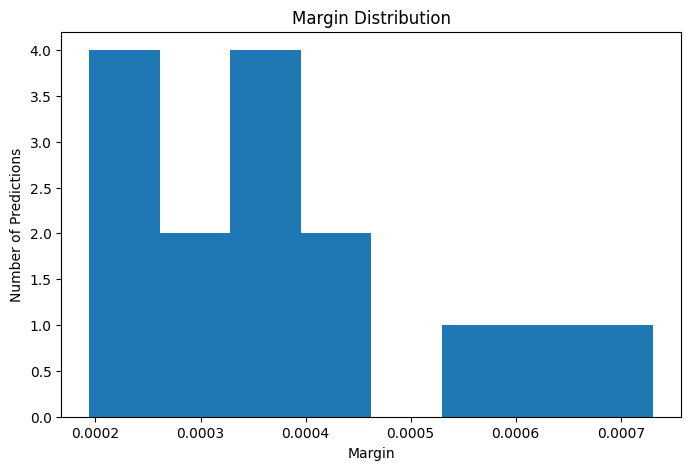

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(margins, bins=8)
plt.xlabel("Margin")
plt.ylabel("Number of Predictions")
plt.title("Margin Distribution")
plt.savefig("margin_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Confusion Matrix

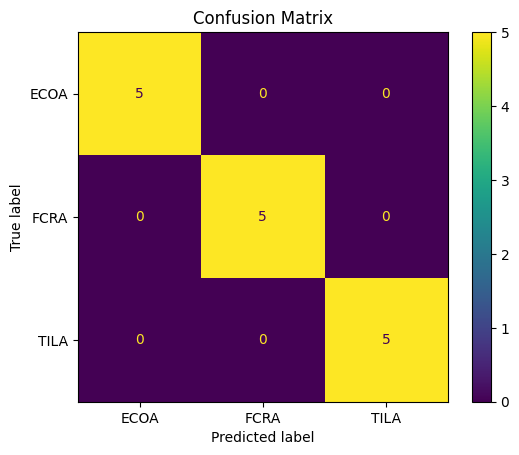

In [18]:
cm = confusion_matrix(y, preds, labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Saved Artifacts

This section confirms that paper-ready figures have been saved successfully.

In [19]:
files = os.listdir()
print("Saved PNG files:")
for f in files:
    if f.endswith(".png"):
        print(f)

Saved PNG files:
entropy_distribution.png
margin_distribution.png
confusion_matrix.png


## Prediction Summary

This table combines the input text, true label, predicted label, entropy, and margin for inspection.

In [20]:
results_df = pd.DataFrame({
    "text": df["text"],
    "true_label": y,
    "predicted_label": preds,
    "entropy": np.round(entropy_scores, 3),
    "margin": np.round(margins, 3)
})

results_df

,text,true_label,predicted_label,entropy,margin
0,loan applicant claims discrimination in credit...,ECOA,ECOA,1.099,0.000
1,creditor considered marital status in lending ...,ECOA,ECOA,1.099,0.000
2,applicant was denied credit unfairly,ECOA,ECOA,1.099,0.000
3,borrower alleges discriminatory lending treatment,ECOA,ECOA,1.099,0.001
4,credit decision may have been influenced by pr...,ECOA,ECOA,1.099,0.000
5,consumer disputes incorrect credit report entry,FCRA,FCRA,1.099,0.000
6,credit report shows inaccurate delinquency,FCRA,FCRA,1.099,0.001
7,agency failed to correct false credit history,FCRA,FCRA,1.099,0.000
8,consumer reporting agency reported inaccurate ...,FCRA,FCRA,1.099,0.001
9,borrower challenges an error in the credit file,FCRA,FCRA,1.099,0.000


## Save Primary Output Artifacts

The results table is saved as an artifact for reporting, reproducibility, and repository upload.

In [21]:
results_df.to_csv("results_run_baseline.csv", index=False)
print("Saved results_run_baseline.csv")

Saved results_run_baseline.csv


## Interpretation

Entropy captures overall uncertainty, while margin reflects the separation between competing classes. Together, these measures support a risk-aware classification system that can abstain when predictions are unreliable.

## Class-Level Error Analysis

In [22]:
print(confusion_matrix(y, preds))

[[5 0 0]
 [0 5 0]
 [0 0 5]]


## Threshold and Abstention Trade-Offs

Different uncertainty thresholds change the balance between system coverage and caution.

In [23]:
thresholds = [0.5, 0.7, 0.9]

for t in thresholds:
    print("Threshold:", t)
    for i in range(len(df)):
        decision = "ABSTAIN" if entropy_scores[i] > t else preds[i]
        print(decision)
    print()

Threshold: 0.5
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN

Threshold: 0.7
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN

Threshold: 0.9
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN
ABSTAIN



## Reproducibility and Multiple Runs

To evaluate stability, the model is trained and evaluated multiple times. Because Word2Vec uses stochastic initialization, repeated runs may produce small variations in predictions and uncertainty metrics. Capturing these runs makes the project more scientific and provides artifacts that document model behavior over time.

In [24]:
run_summaries = []

for run_id in range(1, 4):
    run_model = Word2Vec(
        sentences,
        vector_size=50,
        window=3,
        min_count=1,
        sg=1
    )

    X_run = np.array([sentence_vector(text.lower().split(), run_model) for text in df["text"]])

    run_clf = LogisticRegression()
    run_clf.fit(X_run, y)

    run_preds = run_clf.predict(X_run)
    run_probs = run_clf.predict_proba(X_run)
    run_entropy = [entropy(p) for p in run_probs]

    run_results = pd.DataFrame({
        "text": df["text"],
        "true_label": y,
        "predicted_label": run_preds,
        "entropy": np.round(run_entropy, 3)
    })

    filename = f"results_run{run_id}.csv"
    run_results.to_csv(filename, index=False)

    avg_entropy = np.mean(run_entropy)
    accuracy = np.mean(run_preds == y)

    run_summaries.append({
        "run": run_id,
        "accuracy": round(float(accuracy), 3),
        "average_entropy": round(float(avg_entropy), 3),
        "artifact_file": filename
    })

    print(f"Run {run_id}")
    print("Predictions:", list(run_preds))
    print("Accuracy:", round(float(accuracy), 3))
    print("Average Entropy:", round(float(avg_entropy), 3))
    print("Saved:", filename)
    print()

Run 1
Predictions: ['ECOA', 'ECOA', 'ECOA', 'ECOA', 'ECOA', 'FCRA', 'FCRA', 'FCRA', 'FCRA', 'FCRA', 'TILA', 'TILA', 'TILA', 'TILA', 'TILA']
Accuracy: 1.0
Average Entropy: 1.099
Saved: results_run1.csv

Run 2
Predictions: ['ECOA', 'ECOA', 'ECOA', 'ECOA', 'ECOA', 'FCRA', 'FCRA', 'FCRA', 'FCRA', 'FCRA', 'TILA', 'TILA', 'TILA', 'TILA', 'TILA']
Accuracy: 1.0
Average Entropy: 1.099
Saved: results_run2.csv

Run 3
Predictions: ['ECOA', 'ECOA', 'ECOA', 'ECOA', 'ECOA', 'FCRA', 'FCRA', 'FCRA', 'FCRA', 'FCRA', 'TILA', 'TILA', 'TILA', 'TILA', 'TILA']
Accuracy: 1.0
Average Entropy: 1.099
Saved: results_run3.csv



## Multi-Run Summary

This summary captures stability across repeated runs and identifies the output artifacts generated for each run.

In [25]:
run_summary_df = pd.DataFrame(run_summaries)
run_summary_df

,run,accuracy,average_entropy,artifact_file
0,1,1.0,1.099,results_run1.csv
1,2,1.0,1.099,results_run2.csv
2,3,1.0,1.099,results_run3.csv


## Save Multi-Run Summary Artifact

In [26]:
run_summary_df.to_csv("run_summary.csv", index=False)
print("Saved run_summary.csv")

Saved run_summary.csv


## Artifact Inventory

This section lists the generated artifacts that can be uploaded to GitHub, Google Drive, or another shared repository for inclusion in the final report.

In [27]:
artifact_files = sorted([f for f in os.listdir() if f.endswith(".png") or f.endswith(".csv") or f.endswith(".ipynb")])
print("Artifacts generated in this session:")
for f in artifact_files:
    print(f)

Artifacts generated in this session:
confusion_matrix.png
entropy_distribution.png
margin_distribution.png
results_run1.csv
results_run2.csv
results_run3.csv
results_run_baseline.csv
run_summary.csv


## Governance

This system is designed for decision support rather than autonomous regulatory decision-making. Uncertainty-aware abstention reduces the risk of overconfident errors and supports human review in ambiguous cases.

## Privacy and Data Handling

This notebook uses a synthetic dataset. In real-world deployment, sensitive financial or personal text would require strong governance around privacy, access control, and data retention.

## Limitations

- Small dataset  
- Static embeddings  
- Limited contextual understanding  
- Limited domain coverage  
- Minor variation across runs due to stochastic training  

## Future Work

Potential next steps include:
- contextual embeddings such as BERT
- retrieval-augmented classification
- larger and more realistic regulatory datasets
- improved uncertainty calibration

## Conclusion

This project demonstrates a complete pipeline for regulatory classification with uncertainty estimation. By combining semantic representation, probabilistic classification, and abstention logic, the system supports more reliable and risk-aware decision-making. Multiple runs further document model stability and provide reproducible artifacts for reporting.

In [28]:
print("Rows:", len(df))
print("X shape:", X.shape)
print("Predictions:", len(preds))
print("Entropy values:", len(entropy_scores))
print("Margins:", len(margins))
print("Artifacts found:", len(artifact_files))

Rows: 15
X shape: (15, 50)
Predictions: 15
Entropy values: 15
Margins: 15
Artifacts found: 8


## Artifact Availability

The notebook, figures, and saved result files are uploaded to both shared repositories GitHub and Google Drive. These materials form the artifact package referenced in the final report.

In [29]:
from google.colab import files

In [30]:
files.download("entropy_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
files.download("margin_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
files.download("results_run_baseline.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
files.download("run_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
import os
print(sorted(os.listdir()))

['.config', 'confusion_matrix.png', 'entropy_distribution.png', 'margin_distribution.png', 'results_run1.csv', 'results_run2.csv', 'results_run3.csv', 'results_run_baseline.csv', 'run_summary.csv', 'sample_data']


In [ ]:
from google.colab import files

to_download = [
    "entropy_distribution.png",
    "margin_distribution.png",
    "confusion_matrix.png",
    "results_run_baseline.csv",
    "results_run1.csv",
    "results_run2.csv",
    "results_run3.csv",
    "run_summary.csv"
]

for f in to_download:
    files.download(f)